In [1]:
! pip install -e .
! pip install lifelines


Obtaining file:///home/jovyan/Precipitation_paper
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for precip_helper (pyproject.toml) ... done
  Created wheel for precip_helper: filename=precip_helper-0.1.0-0.editable-py3-none-any.whl size=1298 sha256=6fd0182bbe2e44de53e048b7b0e8c437fa2351f31a3c041d5d034baa22f0813a
  Stored in directory: /tmp/pip-ephem-wheel-cache-9dyrlesx/wheels/0d/d8/f6/0e90ec4164bf3c02bf3bed8ede68ddfb64e3b2ef0023ebb734
Successfully built precip_helper
  Attempting uninstall: precip_helper
    Found existing installation: precip_helper 0.1.0
    Uninstalling precip_helper-0.1.0:
      Successfully uninstalled precip_helper-0.1.0
  Using cached lifelines-0.30.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached autograd-1.9.1-py3-none-any.whl.metadata (6.1 kB)
  Using cached autograd_gamma-0.5

In [2]:
import xarray as xr
import earthaccess
import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import rasterio
import datetime
import pyarrow as pa
import pyarrow.parquet as pq
import os
import numpy as np
from lifelines import CoxPHFitter


warnings.filterwarnings('ignore')
%matplotlib inline

%load_ext autoreload
%autoreload 2


from precip_helper.utils import read_in_fires_and_precip

In [3]:
fires = read_in_fires_and_precip()

In [4]:
fires = fires[fires.l1_ecoregion != "GREAT PLAINS"]

In [5]:
### Reformatting the DF to be in the shape expected by lifelines. 

def get_cox_format(df):
    
    af_mask =  (df['start_off_12hrs'] >= 0) & (df['end_off_12hrs'] <= 1)
    new_df = pd.DataFrame({"UfireID" : df.UfireID.unique(), 
                          "duration" : df.duration.max(),
                          "ended": 1,
                          "precip_during_fire": df[af_mask].precipitation.sum(), 
                          "precip_post_fire": df[df.end_off_12hrs == 1].precipitation.unique(), 
                          "farea_final": df.farea.max(),
                          "n_pixels": df.n_pixels.max(),
                          "GACCAbbrev":  df.GACCAbbrev.unique(), 
                         'l1_ecoregion': df.l1_ecoregion.unique(), 
                         'number_of_rain_events': len(df[af_mask & (df.precipitation > 0)].precipitation)})

    return(new_df)

reg_fr = fires.groupby("UfireID").apply(get_cox_format).reset_index(drop = True)

reg_fr.loc[:, "total_precip"] = reg_fr.precip_post_fire + reg_fr.precip_during_fire


<lifelines.CoxPHFitter: fitted with 3596 total observations, 0 right-censored observations>
             duration col = 'duration'
                event col = 'ended'
      baseline estimation = breslow
   number of observations = 3596
number of events observed = 3596
   partial log-likelihood = -24518.83
         time fit was run = 2026-07-13 18:24:33 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                              
number_of_rain_events -0.13      0.88      0.00           -0.13           -0.12                0.88                0.89

                       cmp to      z      p  -log2(p)
covariate                                            
number_of_rain_events    0.00 -41.04 <0.005       inf
---
Concordance = 0.81
Partial AIC = 49039.67
log-likelihood ratio test = 2665.42 on 1 df
-log2(p) of ll-ratio test = inf

<Axes: xlabel='log(HR) (95% CI)'>

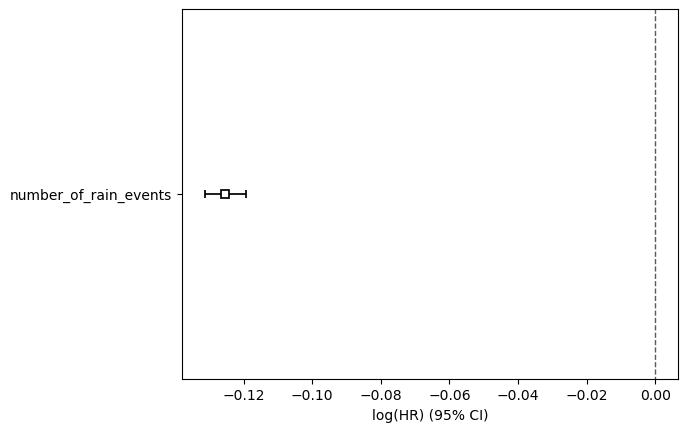

In [6]:
cph = CoxPHFitter()
# df must contain the covariates, the duration (time), and the event observed (boolean/int)

cph.fit(reg_fr[['duration', 'ended', 'number_of_rain_events']], duration_col='duration', event_col='ended')
cph.print_summary()
cph.plot()

Text(0.5, 0, 'Presumably 12-hour increments survived')

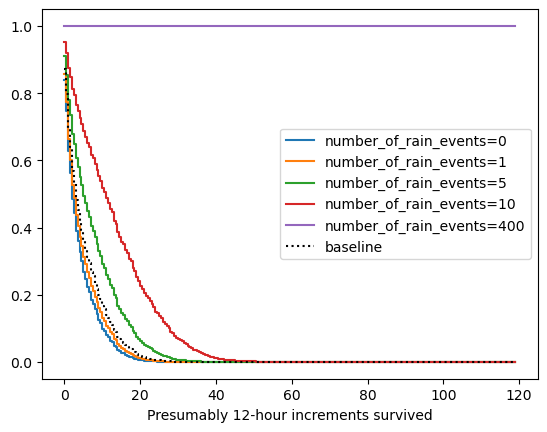

In [7]:
cph.plot_partial_effects_on_outcome(covariates= "number_of_rain_events", values = [0, 1, 5, 10, 400])
plt.xlabel("Presumably 12-hour increments survived")

# Haha, looks like becuase precip varies through time, we are only capturing the effect of more time = more precip. Need to implement a time-varying related model

In [8]:
## get the data into the weird format first. I followed https://lifelines.readthedocs.io/en/latest/Time%20varying%20survival%20regression.html

foo = fires[fires.UfireID == "10047_2022"]

## can the stop be equal to the start????? Lets find out! 

def cox_time_vary_format(df): # cuts off pre-fire precip, but includes post-fire precip 12 hour increment

    post_ig =  (df['start_off_12hrs'] >= 0) & (df.end_off_12hrs < 2) ## we could include more here. 
    df.loc[post_ig & (df.area_growth_at_t_km2.isna()), "area_growth_at_t_km2"] = 0 # include the real zero at the 12 hour mark, negated by the end event?
    end_marker = df[df.end_off_12hrs == 1].start_off_12hrs.values[0]

    
    new_df = pd.DataFrame({ 
                          "start" : df[post_ig].start_off_12hrs,
                          "stop":  df[post_ig].start_off_12hrs + 1,
                          "precipitation": df[post_ig].precipitation,
        
                          "area_growth_at_t_km2": df[post_ig].area_growth_at_t_km2,
                          #n_pixels": df.n_pixels,
                          #"GACCAbbrev":  df.GACCAbbrev.unique(), 
                         #'number_of_rain_events': len(df[post_ig & (df.precipitation > 0)].precipitation), # not time varying right now. 
        
                          })
    new_df.loc[:, "precip_bool"] = new_df.precipitation > 1 ### The more I increase this boolean, the larger the effect. This makes sense because we would expect more rain to put out fires. 
    new_df.loc[:, "precip_cumsum"] = df[post_ig].precipitation.cumsum()
    new_df.loc[:, 'l1_ecoregion'] = df.l1_ecoregion.unique()[0]
    new_df.loc[:, "UfireID"] =  df.UfireID.unique()[0]
    new_df.loc[:, "GACCAbbrev"] = df.GACCAbbrev.unique()[0]
    new_df.loc[:, "ended"] = 0
    new_df.loc[new_df.start == end_marker, "ended"] = 1

    return(new_df)
    
    

In [9]:
tmp = cox_time_vary_format(foo)

tmp

,start,stop,precipitation,area_growth_at_t_km2,precip_bool,precip_cumsum,l1_ecoregion,UfireID,GACCAbbrev,ended
34,0.0,1.0,0.00,4.105439,False,0.00,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
35,1.0,2.0,0.00,0.000000,False,0.00,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
36,2.0,3.0,0.00,0.000000,False,0.00,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
37,3.0,4.0,0.00,0.000000,False,0.00,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
38,4.0,5.0,0.39,0.000000,False,0.39,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
39,5.0,6.0,1.26,0.000000,True,1.65,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
40,6.0,7.0,0.00,0.000000,False,1.65,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
41,7.0,8.0,0.00,0.000000,False,1.65,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
42,8.0,9.0,0.00,0.000000,False,1.65,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0
43,9.0,10.0,0.00,0.000000,False,1.65,EASTERN TEMPERATE FORESTS,10047_2022,SACC,0


In [10]:
fr_tv = fires.groupby("UfireID").apply(cox_time_vary_format).reset_index(drop = True)

Iteration 1: norm_delta = 2.44e-01, step_size = 0.9500, log_lik = -25931.15176, newton_decrement = 1.25e+02, seconds_since_start = 0.1
Iteration 2: norm_delta = 6.99e-02, step_size = 0.9500, log_lik = -26266.82980, newton_decrement = 3.15e+02, seconds_since_start = 0.2
Iteration 3: norm_delta = 3.49e-02, step_size = 0.9500, log_lik = -25916.09348, newton_decrement = 3.95e+01, seconds_since_start = 0.3
Iteration 4: norm_delta = 2.10e-02, step_size = 1.0000, log_lik = -25870.18397, newton_decrement = 6.77e+00, seconds_since_start = 0.3
Iteration 5: norm_delta = 5.53e-03, step_size = 1.0000, log_lik = -25862.59183, newton_decrement = 3.14e-01, seconds_since_start = 0.4
Iteration 6: norm_delta = 2.99e-04, step_size = 1.0000, log_lik = -25862.26748, newton_decrement = 8.32e-04, seconds_since_start = 0.5
Iteration 7: norm_delta = 8.12e-07, step_size = 1.0000, log_lik = -25862.26665, newton_decrement = 6.07e-09, seconds_since_start = 0.6
Convergence completed after 7 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 84373 periods, 3596 subjects, 3596 events>
         event col = 'ended'
number of subjects = 3596
 number of periods = 84373
  number of events = 3596
partial log-likelihood = -25862.27
  time fit was run = 2026-07-13 18:25:03 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
precipitation  0.02      1.02      0.00            0.01            0.02                1.01                1.02

               cmp to     z      p  -log2(p)
covariate                                   
precipitation    0.00 15.27 <0.005    172.41
---
Partial AIC = 51726.53
log-likelihood ratio test = 137.77 on 1 df
-log2(p) of ll-ratio test = 103.27

<Axes: xlabel='log(HR) (95% CI)'>

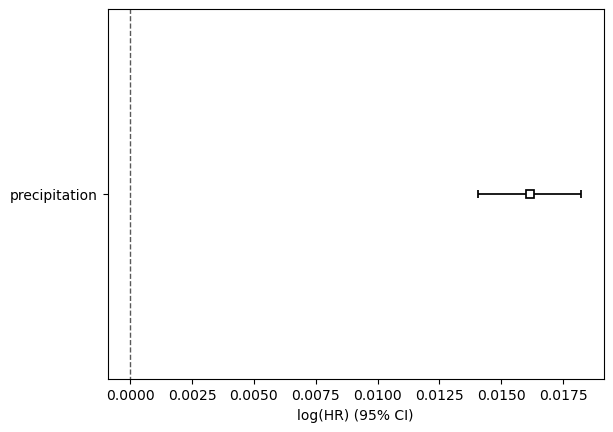

In [11]:
from lifelines import CoxTimeVaryingFitter

ctv = CoxTimeVaryingFitter()
ctv.fit(fr_tv[['start', 'stop', 'precipitation', 'UfireID', 'ended']], id_col='UfireID', event_col="ended", start_col="start", stop_col="stop", show_progress=True)
ctv.print_summary()
ctv.plot()

### Thoughts

- do I need to implment a formal equation (mabe using the *formula* parameter) to describe the non-linear relationship between precip and expected extinguishing / the non-linearity of precip itself? I am unclear on if letting precip time-vary accounts for it's non linearity. I am also not quite sure how to interpret the parameter. Should I jsut use a base level model with a transform (ie do we expect that the amount of precip is propotional to time, and therefore I could tansform the time bit out and get the precip effect?)
- check if number of precip events > effect than amount of precip, or close.
- Do all the assumption checks and critical thinking
- include co-variates?
- wow fireline stuff
- make fit and test datasets.
- could add percent containment!!!
- 

Fun stuff!!!


- cumsum precipp effect < precip effect < << precip boolean effect

In [12]:
#ctv.check_assumptions(training_df = fr_tv[['start', 'stop', 'precip_bool', 'UfireID', 'ended']], advice = True, show_plots = True,)

#cph.check_assumptions(training_df = reg_fr[['duration', 'ended', 'number_of_rain_events']], advice = True, show_plots = True) # Totally breaks the assumptions, becuase it's non linear a wiebull!

Text(0.5, 1.0, 'Cox Hazards model fit to continious precip values')

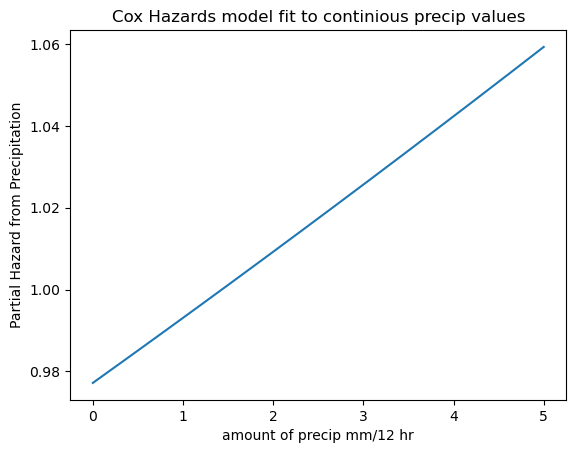

In [13]:
## Make a trial df to show the effect of number of precip events.

## Make a sample tmp
tmp_plot = tmp

tmp_plot.loc[:, 'precipitation']= np.linspace(0, 5, num=len(tmp))
ctv.predict_partial_hazard(tmp_plot[['start', 'stop', 'precipitation']])

plt.plot(tmp_plot.precipitation, ctv.predict_partial_hazard(tmp_plot[['start', 'stop', 'precipitation']]))
plt.ylabel("Partial Hazard from Precipitation")
plt.xlabel("amount of precip mm/12 hr")
plt.title("Cox Hazards model fit to continious precip values")


#tmp_plot.loc[:, 'precip_bool'] = [False, True, False, False, False, False, False, False, False, False, False, False, False, False]
#ctv.predict_partial_hazard(tmp_plot[['start', 'stop', 'precip_bool']])